In [121]:
import numpy as np

from spiderstate.well_ordered_cat_state import *
from spidercat.circuit_extraction import CatStateExtractor, StimBuilder

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[(0, {'chunk_idx': 0}), (1, {'is_mark': True, 'chunk_idx': 0}), (2, {'is_mark': True, 'chunk_idx': 0}), (3, {'chunk_idx': 1}), (4, {'chunk_idx': 1}), (5, {'chunk_idx': 1}), (6, {'chunk_idx': 1}), (7, {'chunk_idx': 1}), (8, {'chunk_idx': 1}), (9, {'is_mark': False, 'is_flag': False, 'original_edge': (0, 5), 'chunk_idx': 1}), (10, {'is_mark': True, 'is_flag': False, 'original_edge': (0, 2), 'chunk_idx': 1}), (11, {'is_mark': True, 'is_flag': False, 'original_edge': (0, 1), 'chunk_idx': 1}), (12, {'is_mark': True, 'is_flag': False, 'original_edge': (1, 4), 'chunk_idx': 1}), (13, {'is_mark': True, 'is_flag': False, 'original_edge': (1, 3), 'chunk_idx': 1}), (14, {'is_mark': True, 'is_flag': False, 'original_edge': (2, 3), 'chunk_idx': 1}), (15, {'is_mark': True, 'is_flag': False, 'original_edge': (2, 4), 'chunk_idx': 1}), (16, {'is_mark': True, 'is_flag': False, 'original_edge': (3, 5), 'chunk_idx': 1}), (17, {'is_mark': True, 'is_flag': False, 'original_edge': (4, 5), 'chunk_idx': 1})]


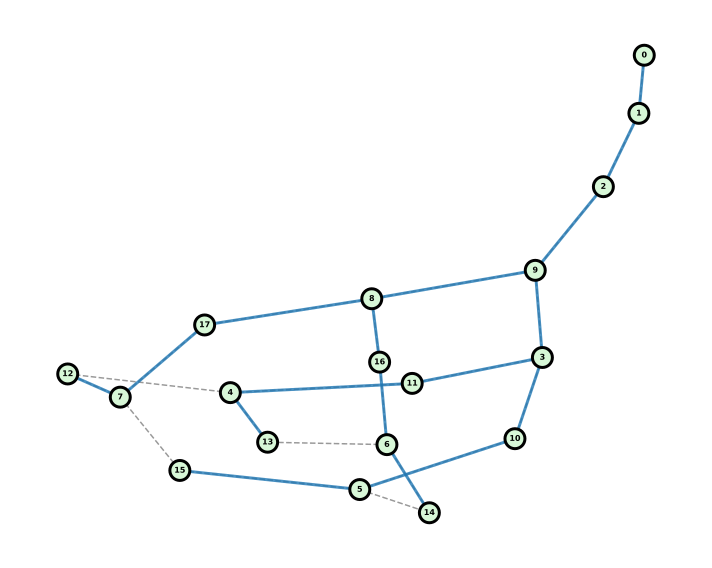

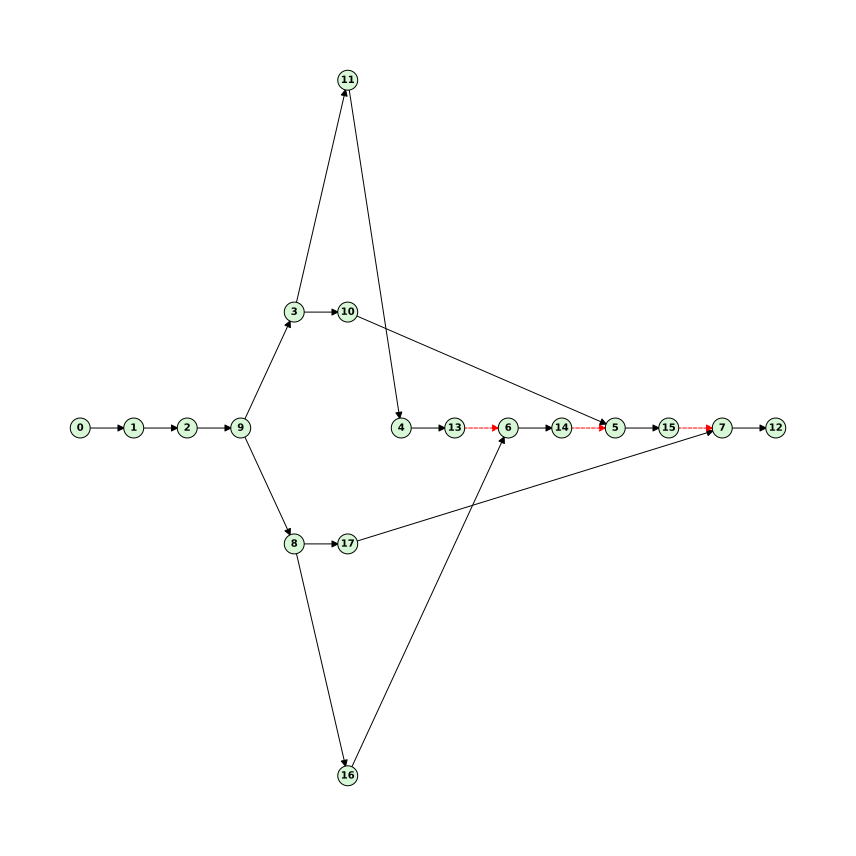

In [132]:
ns, t = [2,8], 3

graph, forest, roots, dependency_dag, edge = well_ordered_composite_cat_state_data(ns, t, regenerate_graph=True, force_generate=True)

from matplotlib import pyplot as plt
from spidercat.draw import display_digraph, draw_forest_on_graph

print(graph.nodes.data())
draw_forest_on_graph(graph, forest)
plt.show()
display_digraph(dependency_dag)
plt.show()

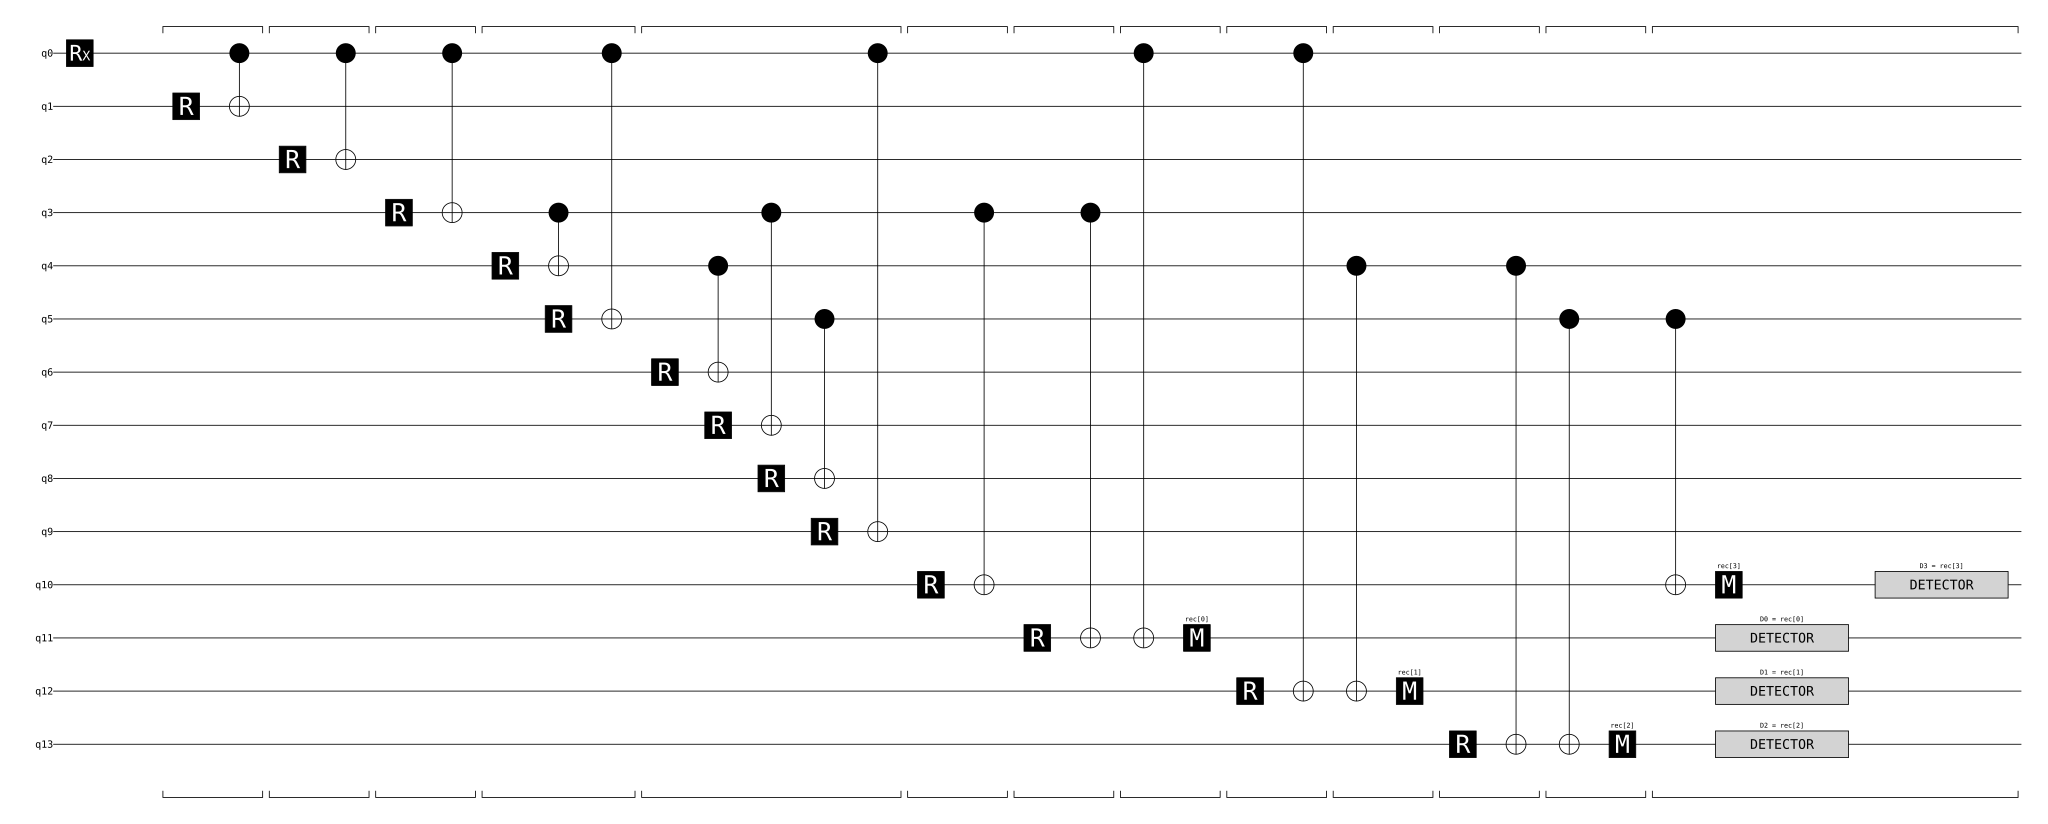

In [133]:
extractor = CatStateExtractor(StimBuilder(), verbose=False)
circuit = extractor.extract(graph, forest, roots, dependency_dag)
circuit.diagram('timeline-svg')

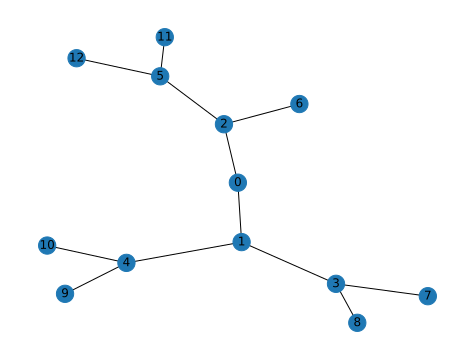

In [72]:
n = 7
def create_balanced_tree(n):
    """
    Constructs a well-balanced binary tree with exactly n leaves using NetworkX.
    """
    G = nx.Graph()
    if n < 1:
        return G
    if n == 1:
        G.add_node(0)
        return G

    # A complete binary tree with 2n - 1 nodes always yields exactly n leaves
    total_nodes = 2 * n - 1
    G.add_nodes_from(range(total_nodes))

    # Internal nodes range from 0 to n-2.
    # Connect each internal node i to its left (2i+1) and right (2i+2) children.
    for i in range(n - 1):
        G.add_edge(i, 2 * i + 1)
        G.add_edge(i, 2 * i + 2)

    return G

nx.draw(create_balanced_tree(n), with_labels=True)